# Predicting Severity of US Car Accidents – A Machine Learning Approach

# 1. Importing required Libraries

In [75]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd  # Import the pandas library for data manipulation and analysis, particularly with DataFrames
import matplotlib.pyplot as plt  # Import matplotlib for creating static, interactive, and animated visualizations in Python
import seaborn as sns  # Import Seaborn for enhanced data visualization based on Matplotlib, for better aesthetics and easier syntax
import numpy as np  # Import NumPy for efficient numerical operations, array manipulations, and mathematical functions
from wordcloud import WordCloud # Import the WordCloud class from the wordcloud library to create word cloud visualizations

# Importing modules for handling imbalanced datasets. SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE  # Import SMOTE to address class imbalance by generating synthetic samples

# Importing modules for model training and evaluation
from sklearn.model_selection import train_test_split  # Import train_test_split to divide the dataset into training and testing subsets
from sklearn.linear_model import LogisticRegression  # Import Logistic Regression model for binary classification tasks
from sklearn.preprocessing import StandardScaler  # Import StandardScaler to standardize features by removing mean & scaling unit variance

# Importing evaluation metrics to assess model performance
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             precision_score, recall_score, f1_score)  # Import various metrics for model evaluation

# Importing ensemble methods for classification
from sklearn.ensemble import RandomForestClassifier  # Import Random Forest classifier for ensemble learning using decision trees
from sklearn.ensemble import GradientBoostingClassifier  # Import Gradient Boosting classifier for boosting learners into a strong ones

# Import necessary libraries for hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import nltk  # Import the Natural Language Toolkit (NLTK) for natural language processing tasks
from nltk.corpus import stopwords  # Import stopwords from NLTK for filtering out common words that may not contribute to text analysis
import string  # Import string for common string operations and manipulation
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder to convert categorical labels into numerical format for model training

# 2. Loading US Car Accidents Dataset

In [18]:
# Loading the CSV Data file into a dataset
file_path = 'US_Accidents_March23.csv'
data = pd.read_csv(file_path)

# Displaying the data in the dataframe to validate if the data is loaded
print(data.head(5))

    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False  False           False          F

# 3. Data Discovery

# 3.1. Understanding the Dataset

### 3.2.1. Check for duplicate rows

In [101]:
# Checking for duplicate rows
duplicate_rows = data[data.duplicated()]

# Displaying the duplicate rows (if any)
print(duplicate_rows)

Empty DataFrame
Columns: [ID, Source, Severity, Start_Time, End_Time, Start_Lat, Start_Lng, End_Lat, End_Lng, Distance(mi), Description, Street, City, County, State, Zipcode, Country, Timezone, Airport_Code, Weather_Timestamp, Temperature(F), Wind_Chill(F), Humidity(%), Pressure(in), Visibility(mi), Wind_Direction, Wind_Speed(mph), Precipitation(in), Weather_Condition, Amenity, Bump, Crossing, Give_Way, Junction, No_Exit, Railway, Roundabout, Station, Stop, Traffic_Calming, Traffic_Signal, Turning_Loop, Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight]
Index: []

[0 rows x 46 columns]


### 3.1.2. Understanding the Dataset

In [103]:
# Displaying the Row and Column Counts to understand the shape of the dataset
data.shape

(7728394, 46)

### 3.1.3. Checking the Class Balance of Target Variables

In [105]:
# Counting the number of records for each severity level
severity_counts = data['Severity'].value_counts()

# Displaying the counts
print(severity_counts)

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64


### 3.1.4. Understanding the Data Type of Features

In [107]:
# Displaying the datatypes of all features
print(data.dtypes)

ID                        object
Source                    object
Severity                   int64
Start_Time                object
End_Time                  object
Start_Lat                float64
Start_Lng                float64
End_Lat                  float64
End_Lng                  float64
Distance(mi)             float64
Description               object
Street                    object
City                      object
County                    object
State                     object
Zipcode                   object
Country                   object
Timezone                  object
Airport_Code              object
Weather_Timestamp         object
Temperature(F)           float64
Wind_Chill(F)            float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction            object
Wind_Speed(mph)          float64
Precipitation(in)        float64
Weather_Condition         object
Amenity                     bool
Bump      

### 3.1.5. Check the volume of missing values on features

In [109]:
# Counting the number of missing values in each feature
missing_counts = data.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts[missing_counts > 0])

End_Lat                  3402762
End_Lng                  3402762
Description                    5
Street                     10869
City                         253
Zipcode                     1915
Timezone                    7808
Airport_Code               22635
Weather_Timestamp         120228
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Sunrise_Sunset             23246
Civil_Twilight             23246
Nautical_Twilight          23246
Astronomical_Twilight      23246
dtype: int64


# 4. Data Preprocessing

## 4.1. Validate for Duplicate Records

In [111]:
#searching about duplicated values
data.duplicated().sum()

0

## 4.2. Handle Missing Values

### 4.2.1. Dropping the Columns

In [113]:
# Taking a  a backup of the DataFrame
us_car_acc_df = data.copy()

# Deleting the specified columns
us_car_acc_df.drop(columns=['End_Lat', 'End_Lng','Street','Zipcode','Airport_Code','ID', 'Source', 'Weather_Timestamp', 'Country'], inplace=True)

# Displaying the features in DataFrame to verify changes
us_car_acc_df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'Description', 'City', 'County', 'State', 'Timezone',
       'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [115]:
# Counting the number of missing values in each feature
missing_counts_df = us_car_acc_df.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts_df[missing_counts_df > 0])

Description                    5
City                         253
Timezone                    7808
Temperature(F)            163853
Wind_Chill(F)            1999019
Humidity(%)               174144
Pressure(in)              140679
Visibility(mi)            177098
Wind_Direction            175206
Wind_Speed(mph)           571233
Precipitation(in)        2203586
Weather_Condition         173459
Sunrise_Sunset             23246
Civil_Twilight             23246
Nautical_Twilight          23246
Astronomical_Twilight      23246
dtype: int64


### 4.2.2. Deleting records that are missing values on key features

In [117]:
# Deleting records that are missing values on key features: Weather_Condition, Sunrise_Sunset, Civil_Twilight, 
# Nautical_Twilight, Astronomical_Twilight, Temperature(F)

# Defining the key features
key_features = ['Description','City', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 
                'Nautical_Twilight', 'Astronomical_Twilight', 'Temperature(F)']

# Dropping records with missing values in the specified key features
us_car_acc_df.dropna(subset=key_features, inplace=True)

In [119]:
# Validating the Dataset for Missing Values after the records are deleted
# Counting the number of missing values in each feature
missing_counts_df = us_car_acc_df.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts_df[missing_counts_df > 0])

Wind_Chill(F)        1814290
Humidity(%)            10097
Pressure(in)            6886
Visibility(mi)         19324
Wind_Direction         36804
Wind_Speed(mph)       414436
Precipitation(in)    2049717
dtype: int64


### 4.2.3. Using Interpolate (Imputation) method to fill missing values

In [121]:
# Defining the columns for imputation
columns_to_impute = ['Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
                      'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)']

# Applying forward fill with limit
us_car_acc_df[columns_to_impute] = us_car_acc_df[columns_to_impute].ffill(limit=5)

# Applying backward fill with limit
us_car_acc_df[columns_to_impute] = us_car_acc_df[columns_to_impute].bfill(limit=5)

# Displaying the updated DataFrame
print(us_car_acc_df[columns_to_impute])

         Humidity(%)  Pressure(in)  Visibility(mi) Wind_Direction  \
0               91.0         29.68            10.0           Calm   
1              100.0         29.65            10.0           Calm   
2              100.0         29.67            10.0             SW   
3               96.0         29.64             9.0             SW   
4               89.0         29.65             6.0             SW   
...              ...           ...             ...            ...   
7728389         40.0         28.92            10.0              W   
7728390         73.0         29.39            10.0             SW   
7728391         64.0         29.74            10.0            SSW   
7728392         81.0         29.62            10.0             SW   
7728393         47.0         28.63             7.0             SW   

         Wind_Speed(mph)  Precipitation(in)  
0                    3.5               0.02  
1                    3.5               0.00  
2                    3.5         

In [123]:
# Validating the Dataset for Missing Values are handled using Imputation method
# Counting the number of missing values in each feature
missing_counts_df = us_car_acc_df.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts_df[missing_counts_df > 0])

Wind_Chill(F)        1814290
Pressure(in)               9
Visibility(mi)             7
Wind_Direction             2
Wind_Speed(mph)         6447
Precipitation(in)    1323270
dtype: int64


Understanding Precipitation(in) is crucial for car accident analysis because rain, snow, and ice drastically reduce tire traction and driver visibility, increasing crash risk and severity, with heavier precipitation leading to higher crash rates and longer stopping distances, impacting safety strategies and infrastructure design. Therefore, I am removing the records that have missing value (NaN) in the column, Precipitation(in).

Deleting records with missing values (NaN) for Wind_Speed(mph) is a valid and crucial step if the goal is to calculate the Wind_Chill(F) value for all data points. 
The wind chill temperature index formula, as defined by the National Weather Service (NWS), requires both the air temperature (T) in Fahrenheit and the wind speed (V) in miles per hour as essential inputs to calculate the wind chill value. 

Wind chill (°F) = 35.74 + 0.6215T - 35.75(V^0.16) + 0.4275T(V^0.16)

T = Air Temperature in Fahrenheit (°F)
V = Wind Speed in miles per hour (mph) 

In [125]:
# Deleting records that are missing values on key features: Weather_Condition, Sunrise_Sunset, Civil_Twilight, 
# Nautical_Twilight, Astronomical_Twilight, Temperature(F)

# Defining the key features
key_features = ['Pressure(in)','Visibility(mi)','Wind_Direction','Precipitation(in)','Wind_Speed(mph)']

# Dropping records with missing values in the specified key features
us_car_acc_df.dropna(subset=key_features, inplace=True)

# Understanding the shape of the dataset
us_car_acc_df.shape

(6183906, 37)

In [127]:
# Validating the Dataset for Missing Values are handled by deleting records with missing values on Percipitation and Wind Speed features
# Counting the number of missing values in each feature
missing_counts_df = us_car_acc_df.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts_df[missing_counts_df > 0])

Wind_Chill(F)    684496
dtype: int64


### 4.2.4. Using Scientific Method to populate the missing values in Wind Chill feature

In [129]:
# Defining a function to calculate Wind Chill
def calculate_wind_chill(temp, wind_speed):
    if wind_speed > 0:  # Remove the upper temperature limit
        wind_chill = (35.74 + (0.6215 * temp) - 
                      (35.75 * (wind_speed ** 0.16)) + 
                      (0.4275 * temp * (wind_speed ** 0.16)))
        return wind_chill
    return np.nan 

# Retrieving the list of row indices where Wind Chill feature have missing value
mask = us_car_acc_df['Wind_Chill(F)'].isna()

# Calling the function to calculate and update Wind Chill column using scientific method
us_car_acc_df.loc[mask, 'Wind_Chill(F)'] = us_car_acc_df.loc[mask].apply(
    lambda row: calculate_wind_chill(row['Temperature(F)'], row['Wind_Speed(mph)']),
    axis=1
)

# Display the updated DataFrame to validate the results
print(us_car_acc_df[['Temperature(F)', 'Wind_Speed(mph)', 'Wind_Chill(F)']].head(5))

   Temperature(F)  Wind_Speed(mph)  Wind_Chill(F)
0            36.9              3.5      34.264737
1            37.9              3.5      35.408617
2            36.0              3.5      33.300000
3            35.1              4.6      31.000000
4            36.0              3.5      33.300000


In [131]:
# Validating the Dataset for Missing Values are handled using scientific method
# Counting the number of missing values in each feature
missing_counts_df = us_car_acc_df.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts_df[missing_counts_df > 0])

Wind_Chill(F)    10373
dtype: int64


In [133]:
# Deleting records that are missing values on key features: Wind_Chill(F)
# Defining the key features
key_features = ['Wind_Chill(F)']

# Dropping records with missing values in the specified key features
us_car_acc_df.dropna(subset=key_features, inplace=True)

# Understanding the shape of the dataset
us_car_acc_df.shape

(6173533, 37)

In [135]:
# Validating the Dataset for Missing Values are handled by deleting the records with missing values in Wind Chill
# Counting the number of missing values in each feature
missing_counts_df = us_car_acc_df.isnull().sum()

# Displaying features with their corresponding count of missing values
print(missing_counts_df[missing_counts_df > 0])

Series([], dtype: int64)


## 4.3. Encoding Categorical Features

## Preparing Data for Encoding

In [137]:
# Understanding unique values on categorical columns for encoding purpose
features = [
   'Weather_Condition', 'Amenity', 'Bump', 
    'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 
    'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 
    'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 
    'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'
]

# Display unique values for each feature
for feature in features:
    unique_values = us_car_acc_df[feature].unique()
    print(f"Unique values for {feature}: {unique_values}")

Unique values for Weather_Condition: ['Light Rain' 'Overcast' 'Mostly Cloudy' 'Rain' 'Light Snow' 'Haze'
 'Scattered Clouds' 'Partly Cloudy' 'Clear' 'Snow'
 'Light Freezing Drizzle' 'Light Drizzle' 'Fog' 'Heavy Rain'
 'Light Freezing Rain' 'Cloudy' 'Drizzle' 'Light Rain Showers' 'Mist'
 'Light Freezing Fog' 'Light Haze' 'Light Thunderstorms and Rain'
 'Shallow Fog' 'Thunderstorms and Rain' 'Fair' 'Smoke'
 'Blowing Dust / Windy' 'Widespread Dust' 'Fair / Windy' 'Rain Showers'
 'Mostly Cloudy / Windy' 'Light Rain / Windy' 'Hail' 'Heavy Drizzle'
 'Volcanic Ash' 'Showers in the Vicinity' 'Thunderstorm'
 'Light Rain Shower' 'Light Rain with Thunder' 'Partly Cloudy / Windy'
 'Thunder in the Vicinity' 'T-Storm' 'Heavy Thunderstorms and Rain'
 'Patches of Fog' 'Thunder' 'Heavy T-Storm' 'Funnel Cloud'
 'Heavy T-Storm / Windy' 'Blowing Snow' 'Light Thunderstorms and Snow'
 'Heavy Snow' 'Light Ice Pellets' 'Ice Pellets' 'N/A Precipitation'
 'Cloudy / Windy' 'Light Fog' 'Snow Grains' 'Snow Showers

In [139]:
def group_weather(condition):
    condition = str(condition).lower()
    if any(word in condition for word in ['clear', 'fair']):
        return 'Clear/Fair'
    elif any(word in condition for word in ['cloudy', 'overcast', 'mostly cloudy', 'partly cloudy', 'scattered clouds']):
        return 'Cloudy'
    elif any(word in condition for word in ['rain', 'drizzle', 'shower', 'precipitation']):
        return 'Rain'
    elif any(word in condition for word in ['snow', 'sleet', 'ice', 'freezing rain', 'wintry mix', 'hail']):
        return 'Snow/Ice'
    elif any(word in condition for word in ['fog', 'mist', 'haze', 'smoke', 'shallow fog', 'patches of fog']):
        return 'Fog/Mist/Haze'
    elif any(word in condition for word in ['thunder', 'storm', 't-storm', 'thunderstorm']):
        return 'Storm/Thunder'
    elif any(word in condition for word in ['dust', 'sand', 'volcanic', 'squalls']):
        return 'Other Precipitation'
    else:
        return 'Extreme/Rare'  # or 'Other'

# Grouping the Weather Conditions into limited categories for encoding purpose
us_car_acc_df['Weather_Group'] = us_car_acc_df['Weather_Condition'].apply(group_weather)

In [141]:
us_car_acc_df['Weather_Group'].unique()

array(['Rain', 'Cloudy', 'Snow/Ice', 'Fog/Mist/Haze', 'Clear/Fair',
       'Other Precipitation', 'Storm/Thunder', 'Extreme/Rare'],
      dtype=object)

In [143]:
# Remove the "Weather_Condition" column
us_car_acc_df = us_car_acc_df.drop(columns=["Weather_Condition"])
us_car_acc_df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'Description', 'City', 'County', 'State', 'Timezone',
       'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)',
       'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way',
       'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
       'Weather_Group'],
      dtype='object')

#### Binning

In [145]:
# List of features to find the highest and lowest values
features = [
    'Temperature(F)',
    'Wind_Chill(F)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Wind_Speed(mph)',
    'Precipitation(in)'
]

# Finding the highest and lowest values for the specified features
highest_values = us_car_acc_df[features].max()
lowest_values = us_car_acc_df[features].min()

# Combining results into a DataFrame for easier readability
results = pd.DataFrame({
    'Highest': highest_values,
    'Lowest': lowest_values
})

# Displaying the results
print(results)

                       Highest  Lowest
Temperature(F)      207.000000   -89.0
Wind_Chill(F)       229.879786   -89.0
Humidity(%)         100.000000     1.0
Pressure(in)         58.630000     0.0
Visibility(mi)      140.000000     0.0
Wind_Speed(mph)    1087.000000     0.0
Precipitation(in)    36.470000     0.0


#### Temperature

In [147]:
# Defining the bin ranges and categories
bins = [-float('inf'), 32, 70, 110, float('inf')]
labels = ['Freezing', 'Moderate', 'Hot', 'Extreme']

# Creating the new Temperature_Range feature
us_car_acc_df['Temperature_Range'] = pd.cut(us_car_acc_df['Temperature(F)'], 
                                                    bins=bins, 
                                                    labels=labels)

# Displaying the modified DataFrame
print(us_car_acc_df[['Temperature(F)', 'Temperature_Range']].head(5))

   Temperature(F) Temperature_Range
0            36.9          Moderate
1            37.9          Moderate
2            36.0          Moderate
3            35.1          Moderate
4            36.0          Moderate


#### Wind Chill

In [149]:
# Defining the bin ranges and categories
bins = [-float('inf'), 0, 30, 50, 70, float('inf')]
labels = ['Extreme Cold', 'Cold', 'Chilly', 'Mild', 'Warm']

# Creating the new Wind_Chill_Range feature
us_car_acc_df['Wind_Chill_Range'] = pd.cut(us_car_acc_df['Wind_Chill(F)'], 
                                             bins=bins, 
                                             labels=labels)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Wind_Chill(F)', 'Wind_Chill_Range']].head(5))

   Wind_Chill(F) Wind_Chill_Range
0      34.264737           Chilly
1      35.408617           Chilly
2      33.300000           Chilly
3      31.000000           Chilly
4      33.300000           Chilly


#### Humidity

In [151]:
# Defining the bin ranges and categories
bins = [0, 30, 60, 100]
labels = ['Dry', 'Comfortable', 'Humid']

# Creating the new Humidity_Range feature
us_car_acc_df['Humidity_Range'] = pd.cut(us_car_acc_df['Humidity(%)'], 
                                           bins=bins, 
                                           labels=labels, 
                                           include_lowest=True)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Humidity(%)', 'Humidity_Range']].head(5))

   Humidity(%) Humidity_Range
0         91.0          Humid
1        100.0          Humid
2        100.0          Humid
3         96.0          Humid
4         89.0          Humid


#### Pressure

In [153]:
# Defining the bin ranges and categories
bins = [-float('inf'), 28.0, 30.0, float('inf')]
labels = ['Very Low Pressure', 'Normal Pressure', 'High Pressure']

# Creating the new Pressure_Range feature
us_car_acc_df['Pressure_Range'] = pd.cut(us_car_acc_df['Pressure(in)'], 
                                           bins=bins, 
                                           labels=labels)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Pressure(in)', 'Pressure_Range']].head(5))

   Pressure(in)   Pressure_Range
0         29.68  Normal Pressure
1         29.65  Normal Pressure
2         29.67  Normal Pressure
3         29.64  Normal Pressure
4         29.65  Normal Pressure


#### Visibility

In [155]:
# Defining the bin ranges and categories
bins = [0, 1, 5, float('inf')]
labels = ['Very Poor Visibility', 'Poor Visibility', 'Good Visibility']

# Creating the new Visibility_Range feature
us_car_acc_df['Visibility_Range'] = pd.cut(us_car_acc_df['Visibility(mi)'], 
                                             bins=bins, 
                                             labels=labels, 
                                             include_lowest=True)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Visibility(mi)', 'Visibility_Range']].head(5))

   Visibility(mi) Visibility_Range
0            10.0  Good Visibility
1            10.0  Good Visibility
2            10.0  Good Visibility
3             9.0  Good Visibility
4             6.0  Good Visibility


#### WindSpeed

In [157]:
# Defining the bin ranges and categories
bins = [0, 5, 20, 40, float('inf')]
labels = ['Calm', 'Breezy', 'Windy', 'Very Windy']

# Creating the new WindSpeed_Range feature
us_car_acc_df['WindSpeed_Range'] = pd.cut(us_car_acc_df['Wind_Speed(mph)'], 
                                            bins=bins, 
                                            labels=labels, 
                                            include_lowest=True)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Wind_Speed(mph)', 'WindSpeed_Range']].head(5))

   Wind_Speed(mph) WindSpeed_Range
0              3.5            Calm
1              3.5            Calm
2              3.5            Calm
3              4.6            Calm
4              3.5            Calm


#### Precipitation

In [159]:
# Defining the bin ranges and categories
bins = [0, 0.5, 2.0, float('inf')]
labels = ['No Precipitation', 'Light', 'Heavy']

# Creating the new Precipitation_Range feature
us_car_acc_df['Precipitation_Range'] = pd.cut(us_car_acc_df['Precipitation(in)'], 
                                               bins=bins, 
                                               labels=labels, 
                                               include_lowest=True)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Precipitation(in)', 'Precipitation_Range']].head(5))

   Precipitation(in) Precipitation_Range
0               0.02    No Precipitation
1               0.00    No Precipitation
2               0.00    No Precipitation
3               0.00    No Precipitation
4               0.00    No Precipitation


In [161]:
# Dropping the specified columns after these columns have been binned
us_car_acc_df = us_car_acc_df.drop(columns=[
    'Precipitation(in)', 
    'Wind_Speed(mph)', 
    'Visibility(mi)', 
    'Pressure(in)', 
    'Humidity(%)', 
    'Wind_Chill(F)', 
    'Temperature(F)'
])

# Displaying the DataFrame to verify the columns have been removed
us_car_acc_df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'Description', 'City', 'County', 'State', 'Timezone',
       'Wind_Direction', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
       'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
       'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset',
       'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight',
       'Weather_Group', 'Temperature_Range', 'Wind_Chill_Range',
       'Humidity_Range', 'Pressure_Range', 'Visibility_Range',
       'WindSpeed_Range', 'Precipitation_Range'],
      dtype='object')

#### Distance (mi)

In [163]:
# Defining the bin ranges (0 to Highest Distance, with a step of 5 miles)
bins = list(range(0, 451, 5))  # Create bins from 0 to 450 (inclusive) in steps of 5
bins.append(float('inf'))  # Add infinity as the upper limit for the last category

# Defining the numeric labels for each bin
labels = list(range(0, 446, 5))  # Numeric labels corresponding to the start of the bin ranges
labels.append(451)  # Unique label for distances greater than 450

# Creating the new Distance_Range feature
us_car_acc_df['Distance_Range'] = pd.cut(us_car_acc_df['Distance(mi)'], 
                                           bins=bins, 
                                           labels=labels, 
                                           include_lowest=True)

# Displaying the first 5 rows to verify the new feature
print(us_car_acc_df[['Distance(mi)', 'Distance_Range']].head(5))

   Distance(mi) Distance_Range
0          0.01              0
1          0.01              0
2          0.01              0
3          0.01              0
4          0.01              0


In [165]:
# Dropping the Distance(mi) column
us_car_acc_df = us_car_acc_df.drop(columns=['Distance(mi)'])

# Displaying the DataFrame to verify the column has been removed
us_car_acc_df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Description', 'City', 'County', 'State', 'Timezone', 'Wind_Direction',
       'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
       'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
       'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight',
       'Nautical_Twilight', 'Astronomical_Twilight', 'Weather_Group',
       'Temperature_Range', 'Wind_Chill_Range', 'Humidity_Range',
       'Pressure_Range', 'Visibility_Range', 'WindSpeed_Range',
       'Precipitation_Range', 'Distance_Range'],
      dtype='object')

## 4.3.1. Binary Encoding

In [167]:
# Defining the list of features for binary encoding
features = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 
    'No_Exit', 'Railway', 'Roundabout', 'Station', 
    'Stop', 'Traffic_Calming', 'Traffic_Signal'
]

# Performing binary encoding
for feature in features:
    us_car_acc_df[feature] = us_car_acc_df[feature].astype(int)

# Displaying the updated DataFrame to verify changes
print(us_car_acc_df[features].head())

   Amenity  Bump  Crossing  Give_Way  Junction  No_Exit  Railway  Roundabout  \
0        0     0         0         0         0        0        0           0   
1        0     0         0         0         0        0        0           0   
2        0     0         0         0         0        0        0           0   
3        0     0         0         0         0        0        0           0   
4        0     0         0         0         0        0        0           0   

   Station  Stop  Traffic_Calming  Traffic_Signal  
0        0     0                0               0  
1        0     0                0               0  
2        0     0                0               1  
3        0     0                0               0  
4        0     0                0               1  


## 4.3.2. Ordinal Encoding

In [169]:
# Defining the list of features for ordinal encoding
features = [
    'Sunrise_Sunset', 
    'Civil_Twilight', 
    'Nautical_Twilight', 
    'Astronomical_Twilight'
]

# Defining the mapping for encoding
ordinal_mapping = {
    'Day': 1,
    'Night': 2
}

# Performing ordinal encoding
for feature in features:
    us_car_acc_df[feature] = us_car_acc_df[feature].map(ordinal_mapping)

# Displaying the updated DataFrame to verify changes
print(us_car_acc_df[features].head())

   Sunrise_Sunset  Civil_Twilight  Nautical_Twilight  Astronomical_Twilight
0               2               2                  2                      2
1               2               2                  2                      1
2               2               2                  1                      1
3               2               1                  1                      1
4               1               1                  1                      1


# 4.3.2. One Hot Encoding

In [171]:
# Perform one-hot encoding for both features
timezone_dummies = pd.get_dummies(us_car_acc_df['Timezone'], prefix='Timezone')
weather_dummies = pd.get_dummies(us_car_acc_df['Weather_Group'], prefix='WEATHER')

# Combine the original DataFrame with the new dummy variables
car_accident_df = pd.concat([us_car_acc_df, timezone_dummies, weather_dummies], axis=1)

# Drop the original categorical columns if needed
car_accident_df = car_accident_df.drop(columns=['Timezone', 'Weather_Group'])

# Display the final DataFrame
print(car_accident_df.head())

   Severity           Start_Time             End_Time  Start_Lat  Start_Lng  \
0         3  2016-02-08 05:46:00  2016-02-08 11:00:00  39.865147 -84.058723   
1         2  2016-02-08 06:07:59  2016-02-08 06:37:59  39.928059 -82.831184   
2         2  2016-02-08 06:49:27  2016-02-08 07:19:27  39.063148 -84.032608   
3         3  2016-02-08 07:23:34  2016-02-08 07:53:34  39.747753 -84.205582   
4         2  2016-02-08 07:39:07  2016-02-08 08:09:07  39.627781 -84.188354   

                                         Description          City  \
0  Right lane blocked due to accident on I-70 Eas...        Dayton   
1  Accident on Brice Rd at Tussing Rd. Expect del...  Reynoldsburg   
2  Accident on OH-32 State Route 32 Westbound at ...  Williamsburg   
3  Accident on I-75 Southbound at Exits 52 52B US...        Dayton   
4  Accident on McEwen Rd at OH-725 Miamisburg Cen...        Dayton   

       County State Wind_Direction  ...  Timezone_US/Mountain  \
0  Montgomery    OH           Calm  ...

## 4.4 Standardizing Feature Names

In [173]:
# Converting feature names to uppercase and replace specified symbols
car_accident_df.columns = (
    car_accident_df.columns
    .str.upper()
    .str.replace('(', '_')
    .str.replace(' ', '_')
    .str.replace(')', '')  # Removing the closing parenthesis
    .str.replace('/', '_')
)

# Displaying the updated column names
print(car_accident_df.columns)

Index(['SEVERITY', 'START_TIME', 'END_TIME', 'START_LAT', 'START_LNG',
       'DESCRIPTION', 'CITY', 'COUNTY', 'STATE', 'WIND_DIRECTION', 'AMENITY',
       'BUMP', 'CROSSING', 'GIVE_WAY', 'JUNCTION', 'NO_EXIT', 'RAILWAY',
       'ROUNDABOUT', 'STATION', 'STOP', 'TRAFFIC_CALMING', 'TRAFFIC_SIGNAL',
       'TURNING_LOOP', 'SUNRISE_SUNSET', 'CIVIL_TWILIGHT', 'NAUTICAL_TWILIGHT',
       'ASTRONOMICAL_TWILIGHT', 'TEMPERATURE_RANGE', 'WIND_CHILL_RANGE',
       'HUMIDITY_RANGE', 'PRESSURE_RANGE', 'VISIBILITY_RANGE',
       'WINDSPEED_RANGE', 'PRECIPITATION_RANGE', 'DISTANCE_RANGE',
       'TIMEZONE_US_CENTRAL', 'TIMEZONE_US_EASTERN', 'TIMEZONE_US_MOUNTAIN',
       'TIMEZONE_US_PACIFIC', 'WEATHER_CLEAR_FAIR', 'WEATHER_CLOUDY',
       'WEATHER_EXTREME_RARE', 'WEATHER_FOG_MIST_HAZE',
       'WEATHER_OTHER_PRECIPITATION', 'WEATHER_RAIN', 'WEATHER_SNOW_ICE',
       'WEATHER_STORM_THUNDER'],
      dtype='object')


In [175]:
# Defining the list of features for binary encoding for the dummy variables created as a part of OneHot Encoding
features = [
    'TIMEZONE_US_CENTRAL', 'TIMEZONE_US_EASTERN', 'TIMEZONE_US_MOUNTAIN', 'TIMEZONE_US_PACIFIC', 'WEATHER_CLEAR_FAIR', 
    'WEATHER_CLOUDY', 'WEATHER_EXTREME_RARE', 'WEATHER_FOG_MIST_HAZE', 'WEATHER_OTHER_PRECIPITATION', 
    'WEATHER_RAIN', 'WEATHER_SNOW_ICE', 'WEATHER_STORM_THUNDER'
]

# Performing binary encoding
for feature in features:
    car_accident_df[feature] = car_accident_df[feature].astype(int)

# Displaying the updated DataFrame to verify changes
print(car_accident_df[features].head())

   TIMEZONE_US_CENTRAL  TIMEZONE_US_EASTERN  TIMEZONE_US_MOUNTAIN  \
0                    0                    1                     0   
1                    0                    1                     0   
2                    0                    1                     0   
3                    0                    1                     0   
4                    0                    1                     0   

   TIMEZONE_US_PACIFIC  WEATHER_CLEAR_FAIR  WEATHER_CLOUDY  \
0                    0                   0               0   
1                    0                   0               0   
2                    0                   0               1   
3                    0                   0               1   
4                    0                   0               1   

   WEATHER_EXTREME_RARE  WEATHER_FOG_MIST_HAZE  WEATHER_OTHER_PRECIPITATION  \
0                     0                      0                            0   
1                     0                      0        

## 4.5. Dropping Less Relevant Features for the Model

In [177]:
# Displaying unique values in the Wind_Direction column
unique_wind_directions = car_accident_df['WIND_DIRECTION'].unique()

# Displaying the unique values
print(unique_wind_directions)

['Calm' 'SW' 'SSW' 'WSW' 'WNW' 'NW' 'West' 'NNW' 'NNE' 'South' 'North'
 'SE' 'SSE' 'ESE' 'East' 'NE' 'ENE' 'E' 'W' 'Variable' 'S' 'VAR' 'CALM'
 'N']


In [179]:
# Dropping the specified features from the DataFrame
car_accident_df = car_accident_df.drop(columns=[ 'WIND_DIRECTION', 'TURNING_LOOP','START_LAT','START_LNG'])

# Displaying the updated DataFrame to verify the changes
car_accident_df.columns

Index(['SEVERITY', 'START_TIME', 'END_TIME', 'DESCRIPTION', 'CITY', 'COUNTY',
       'STATE', 'AMENITY', 'BUMP', 'CROSSING', 'GIVE_WAY', 'JUNCTION',
       'NO_EXIT', 'RAILWAY', 'ROUNDABOUT', 'STATION', 'STOP',
       'TRAFFIC_CALMING', 'TRAFFIC_SIGNAL', 'SUNRISE_SUNSET', 'CIVIL_TWILIGHT',
       'NAUTICAL_TWILIGHT', 'ASTRONOMICAL_TWILIGHT', 'TEMPERATURE_RANGE',
       'WIND_CHILL_RANGE', 'HUMIDITY_RANGE', 'PRESSURE_RANGE',
       'VISIBILITY_RANGE', 'WINDSPEED_RANGE', 'PRECIPITATION_RANGE',
       'DISTANCE_RANGE', 'TIMEZONE_US_CENTRAL', 'TIMEZONE_US_EASTERN',
       'TIMEZONE_US_MOUNTAIN', 'TIMEZONE_US_PACIFIC', 'WEATHER_CLEAR_FAIR',
       'WEATHER_CLOUDY', 'WEATHER_EXTREME_RARE', 'WEATHER_FOG_MIST_HAZE',
       'WEATHER_OTHER_PRECIPITATION', 'WEATHER_RAIN', 'WEATHER_SNOW_ICE',
       'WEATHER_STORM_THUNDER'],
      dtype='object')

## 4.6 Feature Engineering

In [181]:
# Converting the 'START_TIME' column to datetime format, coercing errors to NaT for any unconvertible values
car_accident_df['START_TIME'] = pd.to_datetime(car_accident_df['START_TIME'], errors='coerce')
# Converting the 'END_TIME' column to datetime format, coercing errors to NaT for any unconvertible values
car_accident_df['END_TIME'] = pd.to_datetime(car_accident_df['END_TIME'], errors='coerce')


# Counting the number of records with NaT in the START_TIME field
na_records_st_count = car_accident_df['START_TIME'].isna().sum()
# Counting the number of records with NaT in the END TIMEx field
na_records_end_count = car_accident_df['END_TIME'].isna().sum()
# Displaying the Number of Records with NaT value in 
print(f"Number of records with NaT in START_TIME: {na_records_st_count}")
# Displaying the Number of Records with NaT value in 
print(f"Number of records with NaT in END_TIME: {na_records_end_count}")

Number of records with NaT in START_TIME: 716116
Number of records with NaT in END_TIME: 716116


In [183]:
# Dropping records with NaT in both START_TIME and END_TIME fields
car_accident_df = car_accident_df.dropna(subset=['START_TIME', 'END_TIME'], how='all')

# Displaying the updated DataFrame to verify the changes
print('Data Shape after removing the records',car_accident_df.shape)

Data Shape after removing the records (5457417, 43)


In [185]:
# Validating the features prior to Date Time field Engineering
car_accident_df.columns

Index(['SEVERITY', 'START_TIME', 'END_TIME', 'DESCRIPTION', 'CITY', 'COUNTY',
       'STATE', 'AMENITY', 'BUMP', 'CROSSING', 'GIVE_WAY', 'JUNCTION',
       'NO_EXIT', 'RAILWAY', 'ROUNDABOUT', 'STATION', 'STOP',
       'TRAFFIC_CALMING', 'TRAFFIC_SIGNAL', 'SUNRISE_SUNSET', 'CIVIL_TWILIGHT',
       'NAUTICAL_TWILIGHT', 'ASTRONOMICAL_TWILIGHT', 'TEMPERATURE_RANGE',
       'WIND_CHILL_RANGE', 'HUMIDITY_RANGE', 'PRESSURE_RANGE',
       'VISIBILITY_RANGE', 'WINDSPEED_RANGE', 'PRECIPITATION_RANGE',
       'DISTANCE_RANGE', 'TIMEZONE_US_CENTRAL', 'TIMEZONE_US_EASTERN',
       'TIMEZONE_US_MOUNTAIN', 'TIMEZONE_US_PACIFIC', 'WEATHER_CLEAR_FAIR',
       'WEATHER_CLOUDY', 'WEATHER_EXTREME_RARE', 'WEATHER_FOG_MIST_HAZE',
       'WEATHER_OTHER_PRECIPITATION', 'WEATHER_RAIN', 'WEATHER_SNOW_ICE',
       'WEATHER_STORM_THUNDER'],
      dtype='object')

In [187]:
# Extracting Date Time features
car_accident_df['START_YEAR'] = car_accident_df['START_TIME'].dt.year
car_accident_df['START_MONTH'] = car_accident_df['START_TIME'].dt.month
car_accident_df['START_DAY'] = car_accident_df['START_TIME'].dt.day
car_accident_df['START_HOUR'] = car_accident_df['START_TIME'].dt.hour
car_accident_df['START_WEEKDAY'] = car_accident_df['START_TIME'].dt.weekday  # 0=Monday, 6=Sunday
car_accident_df['START_IS_WEEKDAY'] = (car_accident_df['START_WEEKDAY'] >= 5).astype(int)  # 1=Weekend, 0=Weekday

# Displaying the modified DataFrame to see the new features
print(car_accident_df[['START_TIME', 'START_YEAR', 'START_MONTH', 'START_DAY', 'START_HOUR', 'START_WEEKDAY', 'START_IS_WEEKDAY']].head(2))

           START_TIME  START_YEAR  START_MONTH  START_DAY  START_HOUR  \
0 2016-02-08 05:46:00        2016            2          8           5   
1 2016-02-08 06:07:59        2016            2          8           6   

   START_WEEKDAY  START_IS_WEEKDAY  
0              0                 0  
1              0                 0  


In [189]:
# Extracting features for END_TIME
car_accident_df['END_YEAR'] = car_accident_df['END_TIME'].dt.year
car_accident_df['END_MONTH'] = car_accident_df['END_TIME'].dt.month
car_accident_df['END_DAY'] = car_accident_df['END_TIME'].dt.day
car_accident_df['END_HOUR'] = car_accident_df['END_TIME'].dt.hour
car_accident_df['END_WEEKDAY'] = car_accident_df['END_TIME'].dt.weekday  # 0=Monday, 6=Sunday
car_accident_df['END_IS_WEEKDAY'] = (car_accident_df['END_WEEKDAY'] >= 5).astype(int)  # 1=Weekend, 0=Weekday

# Print the modified DataFrame to see the new features
print(car_accident_df[['END_TIME', 'END_YEAR', 'END_MONTH', 'END_DAY', 'END_HOUR', 'END_WEEKDAY', 'END_IS_WEEKDAY']].head(2))

             END_TIME  END_YEAR  END_MONTH  END_DAY  END_HOUR  END_WEEKDAY  \
0 2016-02-08 11:00:00      2016          2        8        11            0   
1 2016-02-08 06:37:59      2016          2        8         6            0   

   END_IS_WEEKDAY  
0               0  
1               0  


In [191]:
# Validating the features prior to Date Time field Engineering
car_accident_df = car_accident_df.drop(columns=['START_TIME', 'END_TIME'])
car_accident_df.columns

Index(['SEVERITY', 'DESCRIPTION', 'CITY', 'COUNTY', 'STATE', 'AMENITY', 'BUMP',
       'CROSSING', 'GIVE_WAY', 'JUNCTION', 'NO_EXIT', 'RAILWAY', 'ROUNDABOUT',
       'STATION', 'STOP', 'TRAFFIC_CALMING', 'TRAFFIC_SIGNAL',
       'SUNRISE_SUNSET', 'CIVIL_TWILIGHT', 'NAUTICAL_TWILIGHT',
       'ASTRONOMICAL_TWILIGHT', 'TEMPERATURE_RANGE', 'WIND_CHILL_RANGE',
       'HUMIDITY_RANGE', 'PRESSURE_RANGE', 'VISIBILITY_RANGE',
       'WINDSPEED_RANGE', 'PRECIPITATION_RANGE', 'DISTANCE_RANGE',
       'TIMEZONE_US_CENTRAL', 'TIMEZONE_US_EASTERN', 'TIMEZONE_US_MOUNTAIN',
       'TIMEZONE_US_PACIFIC', 'WEATHER_CLEAR_FAIR', 'WEATHER_CLOUDY',
       'WEATHER_EXTREME_RARE', 'WEATHER_FOG_MIST_HAZE',
       'WEATHER_OTHER_PRECIPITATION', 'WEATHER_RAIN', 'WEATHER_SNOW_ICE',
       'WEATHER_STORM_THUNDER', 'START_YEAR', 'START_MONTH', 'START_DAY',
       'START_HOUR', 'START_WEEKDAY', 'START_IS_WEEKDAY', 'END_YEAR',
       'END_MONTH', 'END_DAY', 'END_HOUR', 'END_WEEKDAY', 'END_IS_WEEKDAY'],
      dtype='

In [193]:
# Defining the ordinal categories
temperature_order = ['Freezing', 'Moderate', 'Hot', 'Extreme']
wind_chill_order = ['Extreme Cold', 'Cold', 'Chilly', 'Mild', 'Warm']
humidity_order = ['Dry', 'Comfortable', 'Humid']
pressure_order = ['Very Low Pressure', 'Normal Pressure', 'High Pressure']
visibility_order = ['Very Poor Visibility', 'Poor Visibility', 'Good Visibility']
windspeed_order = ['Calm', 'Breezy', 'Windy', 'Very Windy']
precipitation_order = ['No Precipitation', 'Light', 'Heavy']

# Applying Ordinal Encoding to car_accident_df
car_accident_df['TEMPERATURE_RANGE_CODE'] = pd.Categorical(car_accident_df['TEMPERATURE_RANGE'], 
                                                       categories=temperature_order, ordered=True).codes
car_accident_df['WIND_CHILL_RANGE_CODE'] = pd.Categorical(car_accident_df['WIND_CHILL_RANGE'], 
                                                      categories=wind_chill_order, ordered=True).codes
car_accident_df['HUMIDITY_RANGE_CODE'] = pd.Categorical(car_accident_df['HUMIDITY_RANGE'], 
                                                    categories=humidity_order, ordered=True).codes
car_accident_df['PRESSURE_RANGE_CODE'] = pd.Categorical(car_accident_df['PRESSURE_RANGE'], 
                                                    categories=pressure_order, ordered=True).codes
car_accident_df['VISIBILITY_RANGE_CODE'] = pd.Categorical(car_accident_df['VISIBILITY_RANGE'], 
                                                      categories=visibility_order, ordered=True).codes
car_accident_df['WINDSPEED_RANGE_CODE'] = pd.Categorical(car_accident_df['WINDSPEED_RANGE'], 
                                                     categories=windspeed_order, ordered=True).codes
car_accident_df['PRECIPITATION_RANGE_CODE'] = pd.Categorical(car_accident_df['PRECIPITATION_RANGE'], 
                                                         categories=precipitation_order, ordered=True).codes

# Print the modified DataFrame to see the encoded features
print(car_accident_df[['TEMPERATURE_RANGE_CODE', 'WIND_CHILL_RANGE_CODE', 
                       'HUMIDITY_RANGE_CODE', 'PRESSURE_RANGE_CODE', 
                       'VISIBILITY_RANGE_CODE', 'WINDSPEED_RANGE_CODE', 
                       'PRECIPITATION_RANGE_CODE']].head(5))

   TEMPERATURE_RANGE_CODE  WIND_CHILL_RANGE_CODE  HUMIDITY_RANGE_CODE  \
0                       1                      2                    2   
1                       1                      2                    2   
2                       1                      2                    2   
3                       1                      2                    2   
4                       1                      2                    2   

   PRESSURE_RANGE_CODE  VISIBILITY_RANGE_CODE  WINDSPEED_RANGE_CODE  \
0                    1                      2                     0   
1                    1                      2                     0   
2                    1                      2                     0   
3                    1                      2                     0   
4                    1                      2                     0   

   PRECIPITATION_RANGE_CODE  
0                         0  
1                         0  
2                         0  
3             

In [195]:
# Step 1: Convert DISTANCE_RANGE from categorical to integer
car_accident_df['DISTANCE_RANGE_CODE'] = car_accident_df['DISTANCE_RANGE'].astype(int)

# Step 2: Verify the conversion by displaying unique values
unique_distance_range_int = car_accident_df['DISTANCE_RANGE_CODE'].unique()
print("Unique values in DISTANCE_RANGE_CODE after conversion to int:", unique_distance_range_int)

Unique values in DISTANCE_RANGE_CODE after conversion to int: [  0   5  10  30  35  15  20  25  40  80  90  45  55  50  70 190 335  65
  75  60 115 110 160 210 240  85 140 145 440 100 105 155 175 250  95 180
 120 135 220 130 150]


In [197]:
# Filtering numeric columns before modeling
car_accident_num_df = car_accident_df.select_dtypes(include=['float64', 'int64','int32','int8'])
# Validating Columns in Numerical Dataset
car_accident_num_df.columns

Index(['SEVERITY', 'AMENITY', 'BUMP', 'CROSSING', 'GIVE_WAY', 'JUNCTION',
       'NO_EXIT', 'RAILWAY', 'ROUNDABOUT', 'STATION', 'STOP',
       'TRAFFIC_CALMING', 'TRAFFIC_SIGNAL', 'SUNRISE_SUNSET', 'CIVIL_TWILIGHT',
       'NAUTICAL_TWILIGHT', 'ASTRONOMICAL_TWILIGHT', 'TIMEZONE_US_CENTRAL',
       'TIMEZONE_US_EASTERN', 'TIMEZONE_US_MOUNTAIN', 'TIMEZONE_US_PACIFIC',
       'WEATHER_CLEAR_FAIR', 'WEATHER_CLOUDY', 'WEATHER_EXTREME_RARE',
       'WEATHER_FOG_MIST_HAZE', 'WEATHER_OTHER_PRECIPITATION', 'WEATHER_RAIN',
       'WEATHER_SNOW_ICE', 'WEATHER_STORM_THUNDER', 'START_YEAR',
       'START_MONTH', 'START_DAY', 'START_HOUR', 'START_WEEKDAY',
       'START_IS_WEEKDAY', 'END_YEAR', 'END_MONTH', 'END_DAY', 'END_HOUR',
       'END_WEEKDAY', 'END_IS_WEEKDAY', 'TEMPERATURE_RANGE_CODE',
       'WIND_CHILL_RANGE_CODE', 'HUMIDITY_RANGE_CODE', 'PRESSURE_RANGE_CODE',
       'VISIBILITY_RANGE_CODE', 'WINDSPEED_RANGE_CODE',
       'PRECIPITATION_RANGE_CODE', 'DISTANCE_RANGE_CODE'],
      dtype='ob

In [199]:
# Collecting Features from Numerical Dataset
categorical_cols = car_accident_num_df.select_dtypes(include=['object'])
# Validating the Dataframe with numerical features
categorical_cols.nunique()

Series([], dtype: float64)

In [212]:
# Retrieving the data types of all columns in the numerical features
data_types = car_accident_num_df.dtypes

# Displaying the data types of numerical features
print(data_types)

SEVERITY                       int64
AMENITY                        int64
BUMP                           int64
CROSSING                       int64
GIVE_WAY                       int64
JUNCTION                       int64
NO_EXIT                        int64
RAILWAY                        int64
ROUNDABOUT                     int64
STATION                        int64
STOP                           int64
TRAFFIC_CALMING                int64
TRAFFIC_SIGNAL                 int64
SUNRISE_SUNSET                 int64
CIVIL_TWILIGHT                 int64
NAUTICAL_TWILIGHT              int64
ASTRONOMICAL_TWILIGHT          int64
TIMEZONE_US_CENTRAL            int64
TIMEZONE_US_EASTERN            int64
TIMEZONE_US_MOUNTAIN           int64
TIMEZONE_US_PACIFIC            int64
WEATHER_CLEAR_FAIR             int64
WEATHER_CLOUDY                 int64
WEATHER_EXTREME_RARE           int64
WEATHER_FOG_MIST_HAZE          int64
WEATHER_OTHER_PRECIPITATION    int64
WEATHER_RAIN                   int64
W

# 5. Exploratiry Data Analysis

## 5.1. Statistics

In [218]:
# Use describe() for the SEVERITY column
severity_description = car_accident_num_df['SEVERITY'].describe()

# Display the description
print(severity_description)

count    5.457417e+06
mean     1.197347e+00
std      4.850259e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: SEVERITY, dtype: float64


## 5.2. Visualization

In [187]:
car_accident_df.columns

Index(['SEVERITY', 'DESCRIPTION', 'CITY', 'COUNTY', 'STATE', 'AMENITY', 'BUMP',
       'CROSSING', 'GIVE_WAY', 'JUNCTION', 'NO_EXIT', 'RAILWAY', 'ROUNDABOUT',
       'STATION', 'STOP', 'TRAFFIC_CALMING', 'TRAFFIC_SIGNAL',
       'SUNRISE_SUNSET', 'CIVIL_TWILIGHT', 'NAUTICAL_TWILIGHT',
       'ASTRONOMICAL_TWILIGHT', 'TEMPERATURE_RANGE', 'WIND_CHILL_RANGE',
       'HUMIDITY_RANGE', 'PRESSURE_RANGE', 'VISIBILITY_RANGE',
       'WINDSPEED_RANGE', 'PRECIPITATION_RANGE', 'DISTANCE_RANGE',
       'TIMEZONE_US_CENTRAL', 'TIMEZONE_US_EASTERN', 'TIMEZONE_US_MOUNTAIN',
       'TIMEZONE_US_PACIFIC', 'WEATHER_CLEAR_FAIR', 'WEATHER_CLOUDY',
       'WEATHER_EXTREME_RARE', 'WEATHER_FOG_MIST_HAZE',
       'WEATHER_OTHER_PRECIPITATION', 'WEATHER_RAIN', 'WEATHER_SNOW_ICE',
       'WEATHER_STORM_THUNDER', 'START_YEAR', 'START_MONTH', 'START_DAY',
       'START_HOUR', 'START_WEEKDAY', 'START_IS_WEEKDAY', 'END_YEAR',
       'END_MONTH', 'END_DAY', 'END_HOUR', 'END_WEEKDAY', 'END_IS_WEEKDAY',
       'TEMPER

## 5.2.1. Word Cloud - Common Terms in Severity 1 Accident Descriptions (2022)

In [219]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mathan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [213]:
# Filtering the DataFrame for Severity 1 accidents in the year 2022
severity_1_2022_df = car_accident_df[(car_accident_df['SEVERITY'] == 1) & (car_accident_df['START_YEAR'] == 2022)]

# Dropping records where DESCRIPTION is NaN
severity_1_2022_df = severity_1_2022_df.dropna(subset=['DESCRIPTION'])

# Display the updated DataFrame (optional)
severity_1_2022_df.shape

(36837, 61)

In [221]:
# Function to preprocess text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Remove stop words
    stop_words = set(stopwords.words('english'))
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

# Applyinf preprocessing to the DESCRIPTION field
severity_1_2022_df['PROCESSED_DESCRIPTION'] = severity_1_2022_df['DESCRIPTION'].apply(preprocess_text)

all_descriptions = ' '.join(severity_1_2022_df['PROCESSED_DESCRIPTION'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=200).generate(all_descriptions)

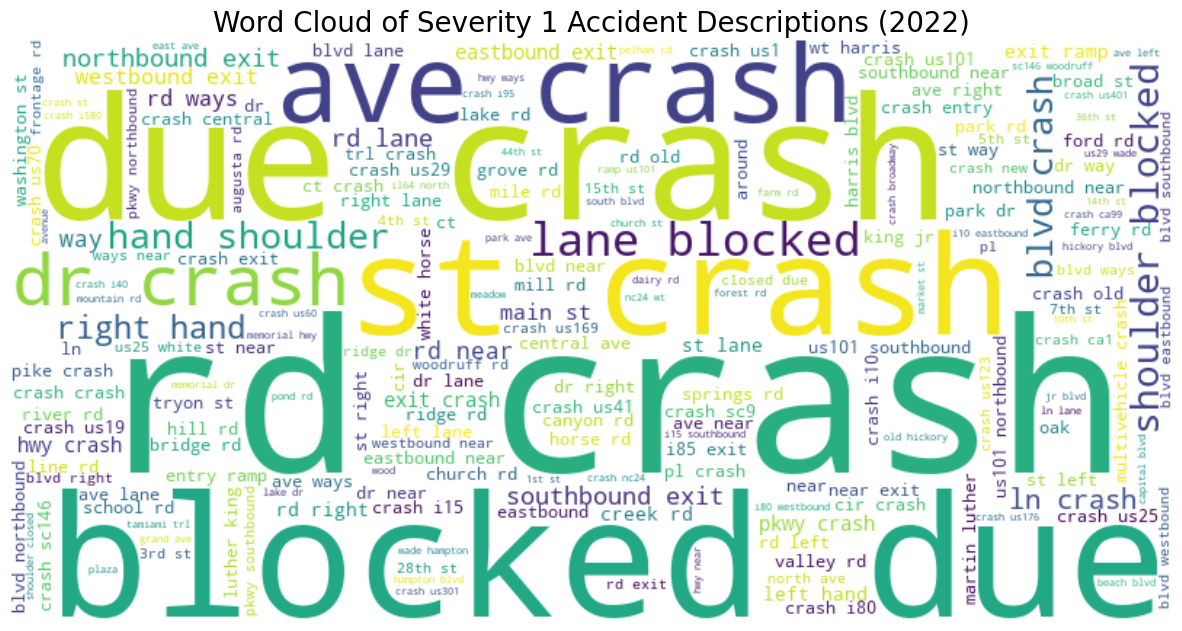

In [227]:
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Disable axes
plt.title("Word Cloud of Severity 1 Accident Descriptions (2022)", fontsize=20)
plt.show()

## 5.2.2. Bar Chart - High Impact States

In [26]:
# Counting the occurrences of each state in the 'State' column of the dataset
state_counts = data["State"].value_counts()

# Converting the state counts series into a DataFrame, reset the index, and sort by counts in descending order
states = pd.DataFrame(state_counts).reset_index().sort_values('count', ascending=False)

# Renaming columns for better readability: 'State' to 'state_code' and 'count' to 'cases'
states.rename(columns={'State': 'state_code', 'count': 'cases'}, inplace=True)

# Defining Dictionary mapping state codes to their full state names
us_states = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas', 'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 
    'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 
    'IA': 'Iowa', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine', 'MD': 'Maryland', 'MA': 'Massachusetts',
    'MI': 'Michigan', 'MN': 'Minnesota', 'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska', 'NV': 'Nevada', 
    'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 
    'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington', 
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

# Adding a new column 'state' to the 'states' DataFrame using the 'state_code' to map the full state names
states['state'] = states['state_code'].map(us_states)

# Displaying the updated DataFrame to show the counts along with the state names
states.head()

,state_code,cases,state
0,CA,1741433,California
1,FL,880192,Florida
2,TX,582837,Texas
3,SC,382557,South Carolina
4,NY,347960,New York


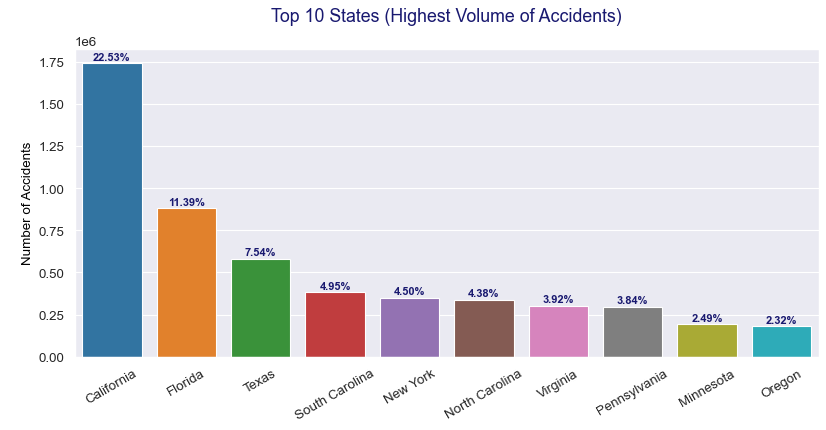

In [60]:
# Creating a figure and axis for the bar plot with specified size and resolution
fig, ax = plt.subplots(figsize=(12, 5), dpi=80)

# Difining the style for the plot to 'ticks'
sns.set_style('ticks')

# Selecting the top 10 states with the highest number of accidents
top_10 = states[:10]

# Creating a list of colors for each bar using the "tab10" palette for distinct colors
bar_colors = sns.color_palette("tab10", n_colors=10)

# Creating the bar plot with the custom colors, using hue for each state
sns.barplot(data=top_10, x='state', y='cases', hue='state', palette=bar_colors, legend=False)

# Defining the title of the plot with specified font size and color
plt.title("Top 10 States (Highest Volume of Accidents)\n", fontdict={'fontsize': 16, 'color': 'MidnightBlue'})

# Defining the label for the Y-axis
plt.ylabel("\nNumber of Accidents", fontdict={'fontsize': 12, 'color': 'black'})

# Rotating the X-axis tick labels for better readability
plt.xticks(rotation=30)

# Removing the label for the X-axis
plt.xlabel(None)

# Calculating the total number of accidents to display percentages on the bars
total_accidents = data.shape[0]

# Annotating each bar with the percentage of total accidents it represents
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2,
            height + 20000,
            '{:.2f}%'.format(height / total_accidents * 100),
            ha="center",
            fontsize=10, weight='bold', color='MidnightBlue')

# Increasing the font size of the axis tick labels
sns.set(rc={'xtick.labelsize': 12, 'ytick.labelsize': 12})

# Customizing Y-axis tick labels to show whole numbers
def format_func(value, _):
    return f'{value:.0f}'  # Format as whole numbers

# Displaying the plot
plt.show()

## 5.2.3. Density Plot - Accident Distribution by Hour of the Day

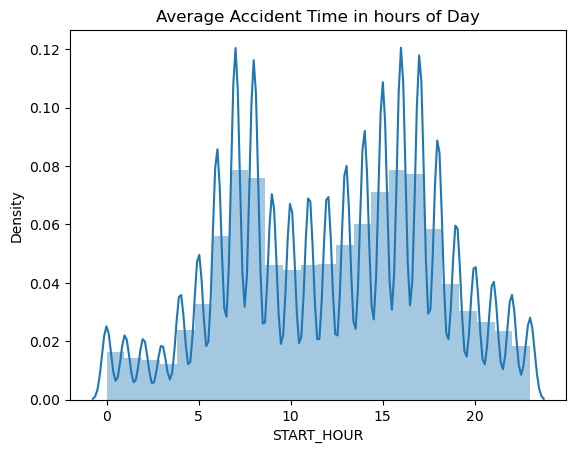

In [270]:
sns.distplot(car_accident_df.START_HOUR,bins=24,norm_hist=True)
plt.title("Average Accident Time in hours of Day")
plt.show()

## 5.2.4. Histogram - Accident Trends by Day of the Week

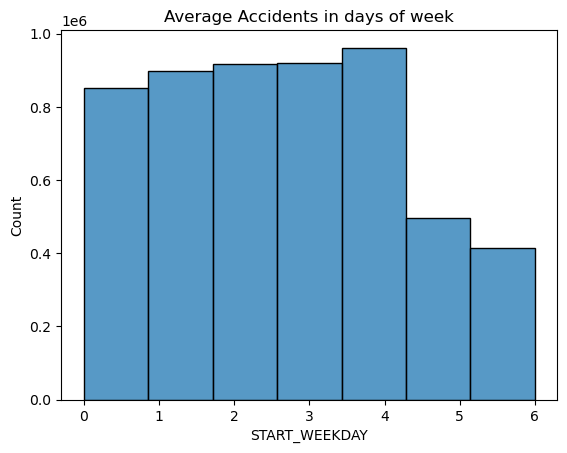

In [277]:
sns.histplot(car_accident_df.START_WEEKDAY,bins=7)
plt.title("Average Accidents in days of week")
plt.show()

## 5.2.5. Scatter Plot - Influence of Temperature in Car Accidents Occurrence

In [288]:
grouped_data = data.groupby('Temperature(F)').size().reset_index(name='accident_count')

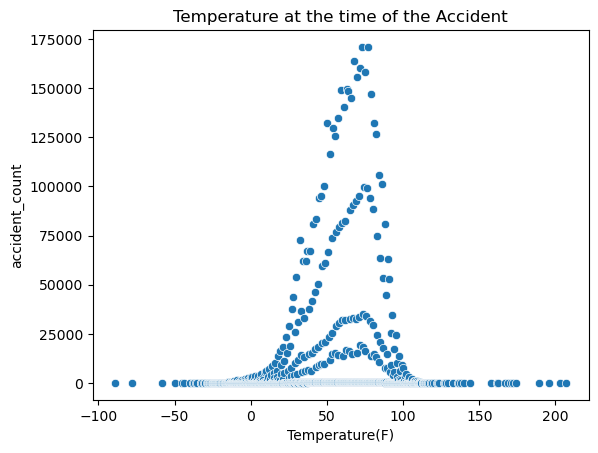

In [292]:
sns.scatterplot(data=grouped_data, x='Temperature(F)', y='accident_count')
plt.title("Temperature at the time of the Accident")
plt.show()

## 5.2.6. Bar Chart - Accident by Weather Condition

In [7]:
def group_weather(condition):
    condition = str(condition).lower()
    if any(word in condition for word in ['clear', 'fair']):
        return 'Clear/Fair'
    elif any(word in condition for word in ['cloudy', 'overcast', 'mostly cloudy', 'partly cloudy', 'scattered clouds']):
        return 'Cloudy'
    elif any(word in condition for word in ['rain', 'drizzle', 'shower', 'precipitation']):
        return 'Rain'
    elif any(word in condition for word in ['snow', 'sleet', 'ice', 'freezing rain', 'wintry mix', 'hail']):
        return 'Snow/Ice'
    elif any(word in condition for word in ['fog', 'mist', 'haze', 'smoke', 'shallow fog', 'patches of fog']):
        return 'Fog/Mist/Haze'
    elif any(word in condition for word in ['thunder', 'storm', 't-storm', 'thunderstorm']):
        return 'Storm/Thunder'
    elif any(word in condition for word in ['dust', 'sand', 'volcanic', 'squalls']):
        return 'Other Precipitation'
    else:
        return 'Extreme/Rare'  # or 'Other'

# Grouping the Weather Conditions into limited categories for encoding purpose
data['Weather_Group'] = data['Weather_Condition'].apply(group_weather)
data['Weather_Group'].unique()

array(['Rain', 'Cloudy', 'Snow/Ice', 'Fog/Mist/Haze', 'Clear/Fair',
       'Extreme/Rare', 'Other Precipitation', 'Storm/Thunder'],
      dtype=object)

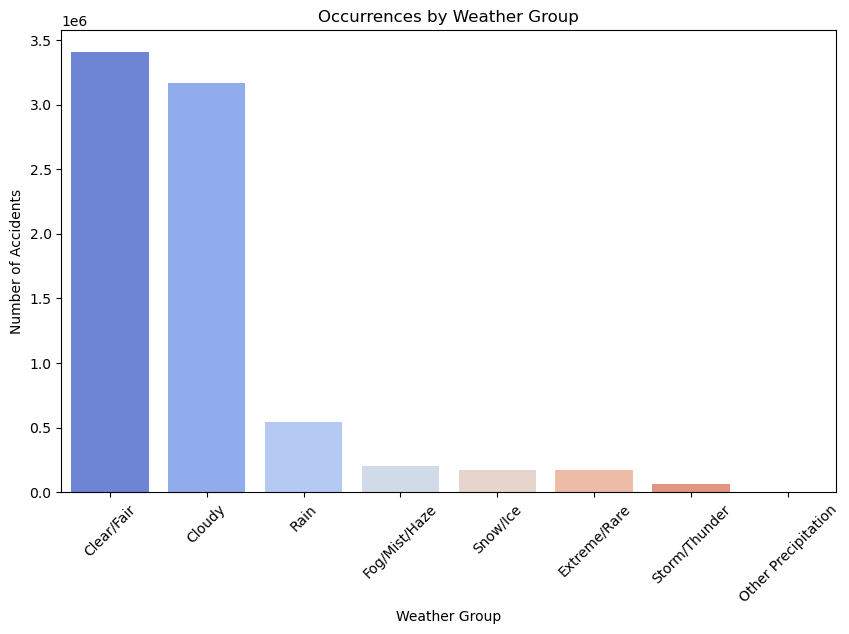

In [13]:
# Count occurrences of each Weather_Group
weather_counts = data['Weather_Group'].value_counts().reset_index()
weather_counts.columns = ['Weather Group', 'Count']

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(data=weather_counts, x='Weather Group', y='Count', hue='Weather Group', palette='coolwarm')
plt.title("Occurrences by Weather Group")
plt.xlabel("Weather Group")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

## 5.2.7. Location Scatter Plot - Accidents by Location

/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


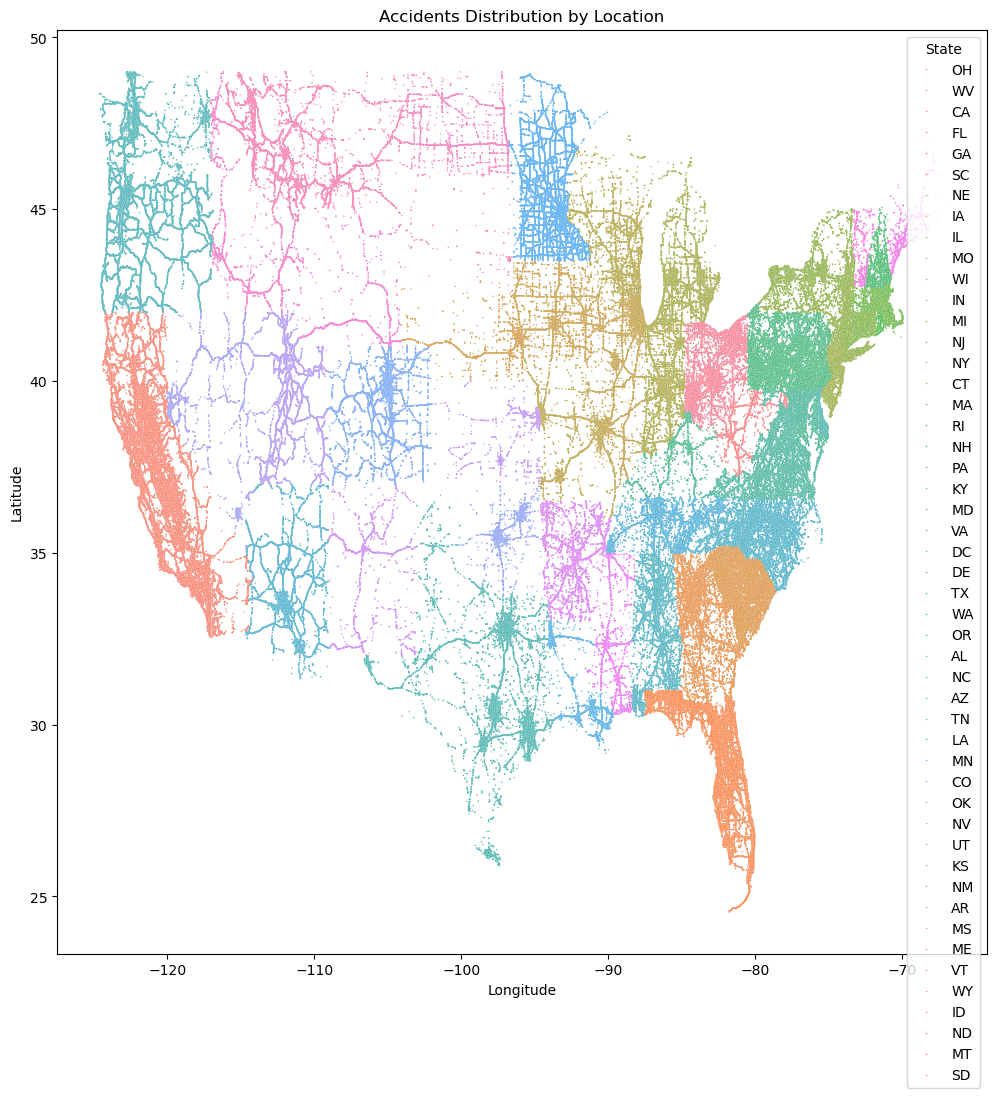

In [20]:
# Creating a location scatter plot using Seaborn
plt.figure(figsize=(12, 12))
sns.scatterplot(x=data.Start_Lng, y=data.Start_Lat, hue=data.State, s=1)

# Defining the Labels and Title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Accidents Distribution by Location')

# Add a legend
plt.legend(title='State')

plt.show()

## 5.2.8. KDE Plot - Distribution of Accident Severity Across States

In [62]:
sample_size = 100000  # Number of samples you want to take

# Take a random sample
random_sample = data.sample(n=sample_size)
random_sample.shape

(100000, 46)

In [77]:
State_le = LabelEncoder()
random_sample['State'] = State_le.fit_transform(random_sample['State'])

<Axes: xlabel='State', ylabel='Density'>

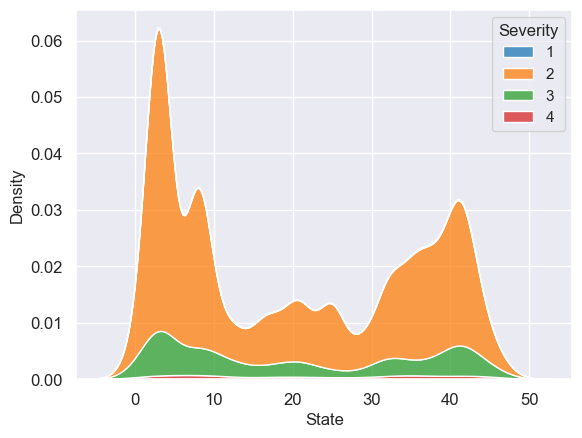

In [79]:
sns.kdeplot(data=random_sample, x = "State", hue="Severity",multiple='stack',palette='tab10')

## 5.2.9. Join Plot (Scatter Plot & Histogram) - Wind Speed Distribution across States

In [84]:
Wind_Speed_mph_le = LabelEncoder()
random_sample['Wind_Speed(mph)'] = Wind_Speed_mph_le.fit_transform(random_sample['Wind_Speed(mph)'])

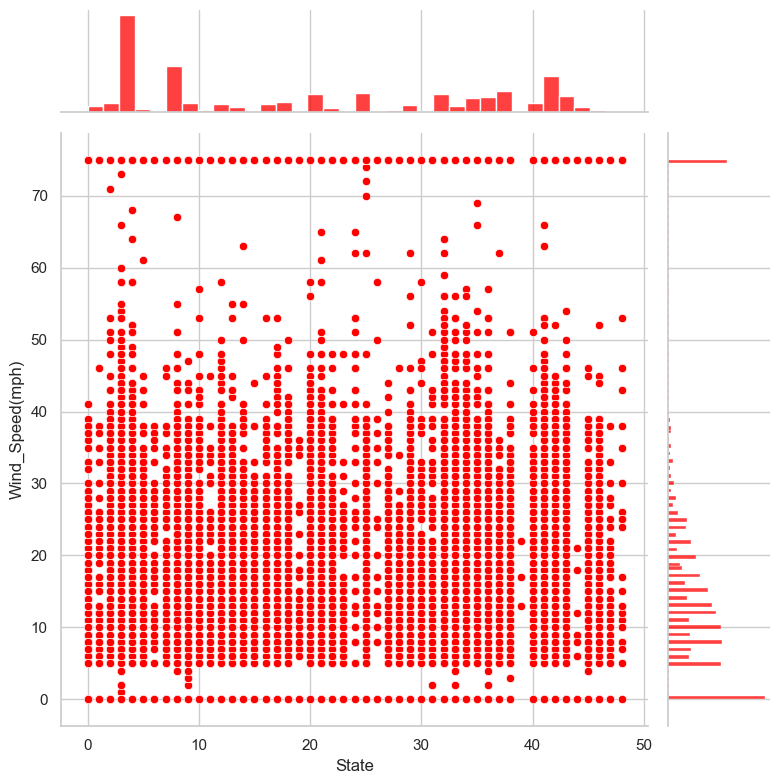

In [98]:
# Adjust the size (height) and color in jointplot
sns.set(style="whitegrid")
joint_plot = sns.jointplot(
    x=random_sample["State"], 
    y=random_sample["Wind_Speed(mph)"], 
    kind='scatter', 
    height=8,  # Increase the plot size
    color='red'  # Change to your preferred color
)

plt.show()

## 5.2.10. Line Chart - Accident Count by Severity Across Years

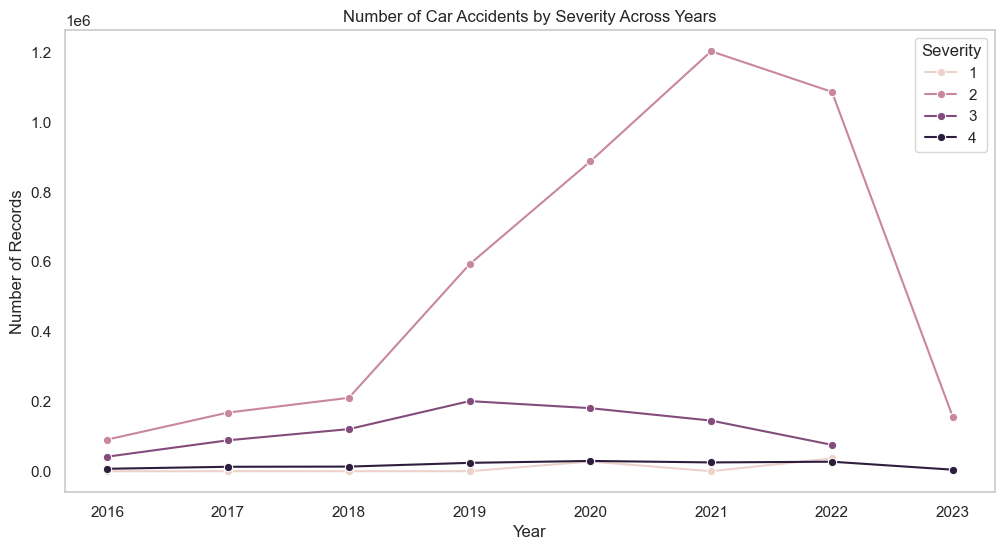

In [203]:
# Group by START_YEAR and SEVERITY, then count number of records
accident_counts = car_accident_num_df.groupby(['START_YEAR', 'SEVERITY']).size().reset_index(name='NUM_RECORDS')

# Create a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=accident_counts, x='START_YEAR', y='NUM_RECORDS', hue='SEVERITY', marker='o')

# Title and labels
plt.title('Number of Car Accidents by Severity Across Years')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(accident_counts['START_YEAR'].unique())  # Ensure all years are displayed on the x-axis
plt.legend(title='Severity')
plt.grid()
plt.show()

## 5.3. Correlation

In [208]:
# Encode categorical variable 'SEVERITY'
label_encoder = LabelEncoder()
car_accident_num_df['SEVERITY'] = label_encoder.fit_transform(car_accident_num_df['SEVERITY'])

# Select numerical features
numerical_features = car_accident_num_df.select_dtypes(include=['int64', 'int32', 'int8', 'float64'])

# Calculate correlation with the target variable 'SEVERITY'
correlation_matrix = numerical_features.corr()

# Get correlations with 'SEVERITY'
severity_correlation = correlation_matrix['SEVERITY'].sort_values(ascending=False)

print(severity_correlation)

SEVERITY                       1.000000
DISTANCE_RANGE_CODE            0.056760
WEATHER_RAIN                   0.048437
JUNCTION                       0.043994
TIMEZONE_US_CENTRAL            0.040982
WEATHER_CLOUDY                 0.039270
START_IS_WEEKDAY               0.038320
WINDSPEED_RANGE_CODE           0.038000
TIMEZONE_US_EASTERN            0.036621
END_IS_WEEKDAY                 0.036457
HUMIDITY_RANGE_CODE            0.036158
PRESSURE_RANGE_CODE            0.034037
START_WEEKDAY                  0.026395
END_WEEKDAY                    0.025234
WEATHER_SNOW_ICE               0.020650
START_HOUR                     0.019857
PRECIPITATION_RANGE_CODE       0.018276
END_HOUR                       0.013354
NAUTICAL_TWILIGHT              0.004029
CIVIL_TWILIGHT                 0.003783
WEATHER_STORM_THUNDER          0.003360
SUNRISE_SUNSET                 0.002780
ASTRONOMICAL_TWILIGHT          0.001458
END_DAY                       -0.000572
WEATHER_EXTREME_RARE          -0.000632


# 6. Building & Evaluating Model

## 6.1. Logistic Regression

In [122]:
# Creating a sample DataFrame with 10% of the original DataFrame
sampled_df = car_accident_num_df.sample(frac=0.01, random_state=42)
sampled_df.shape

(54574, 49)

In [124]:
# Step 1: Define the feature and target variables
X = sampled_df.drop('SEVERITY', axis=1)  # Features
y = sampled_df['SEVERITY']  # Target variable

# Step 2: Split the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Create and fit the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Step 5: Make predictions
y_pred = log_reg.predict(X_test_scaled)

# Step 6: Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Step 7: Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Step 8: Print the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.7967
Precision: 0.7299
Recall: 0.7967
F1-score: 0.7316

Confusion Matrix:
[[   1  141    0    0]
 [   1 8566  201    1]
 [   0 1578  128    0]
 [   0  285   12    1]]

Classification Report:
              precision    recall  f1-score   support

           1       0.50      0.01      0.01       142
           2       0.81      0.98      0.89      8769
           3       0.38      0.08      0.13      1706
           4       0.50      0.00      0.01       298

    accuracy                           0.80     10915
   macro avg       0.55      0.27      0.26     10915
weighted avg       0.73      0.80      0.73     10915



## 6.2. Random Forest

In [126]:
# Creating a sample DataFrame with 10% of the original DataFrame
sampled_df = car_accident_num_df.sample(frac=0.01, random_state=42)
sampled_df.shape

(54574, 49)

In [128]:
# Defining the feature and target variables
X = sampled_df.drop('SEVERITY', axis=1)  # Features
y = sampled_df['SEVERITY']  # Target variable

# Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features2
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Making predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Computing evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Generating confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Displaying the results
print("Random Forest Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Evaluation Metrics:
Accuracy: 0.7993
Precision: 0.7433
Recall: 0.7993
F1-score: 0.7503

Confusion Matrix:
[[  20  120    2    0]
 [  15 8450  296    8]
 [   1 1453  249    3]
 [   1  266   26    5]]

Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.14      0.22       142
           2       0.82      0.96      0.89      8769
           3       0.43      0.15      0.22      1706
           4       0.31      0.02      0.03       298

    accuracy                           0.80     10915
   macro avg       0.53      0.32      0.34     10915
weighted avg       0.74      0.80      0.75     10915



## 6.3 Gradient Boosting

In [130]:
# Creating a sample DataFrame with 10% of the original DataFrame
sampled_df = car_accident_num_df.sample(frac=0.01, random_state=42)
sampled_df.shape

(54574, 49)

In [132]:
# Defining the feature and target variables
X = sampled_df.drop('SEVERITY', axis=1)  # Features
y = sampled_df['SEVERITY']  # Target variable

# Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Making predictions
y_pred_gb = gb_model.predict(X_test_scaled)

# Computing evaluation metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

# Generating confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

# Displaying the results
print("Gradient Boosting Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_gb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Model Evaluation Metrics:
Accuracy: 0.8097
Precision: 0.7700
Recall: 0.8097
F1-score: 0.7467

Confusion Matrix:
[[  22  120    0    0]
 [   9 8655  104    1]
 [   0 1547  157    2]
 [   2  280   12    4]]

Classification Report:
              precision    recall  f1-score   support

           1       0.67      0.15      0.25       142
           2       0.82      0.99      0.89      8769
           3       0.58      0.09      0.16      1706
           4       0.57      0.01      0.03       298

    accuracy                           0.81     10915
   macro avg       0.66      0.31      0.33     10915
weighted avg       0.77      0.81      0.75     10915



## 6.4. Hyperparameter Tuning

### 6.4.1. Grid Search

In [138]:
# Defining the model
model = RandomForestClassifier(random_state=42)

# Defining a smaller parameter grid for Grid Search
param_grid = {
    'n_estimators': [50, 100],              # Reduce the range of trees
    'max_features': ['sqrt'],                # Use 'sqrt' instead of 'auto'
    'max_depth': [None, 10],                 # Simplified max_depth choices
    'criterion': ['gini']                    # Focus on one criterion
}

# Implementing GridSearch (Reducing number of folds to 3)
grid_search = GridSearchCV(estimator=model, 
                           param_grid=param_grid, 
                           scoring='accuracy', 
                           cv=3,       # Reduced cross-validation folds
                           verbose=2, 
                           n_jobs=-1,
                           error_score=0.0)  # Use all available cores

# Fitting the model (consider sampling if necessary)
grid_search.fit(X_train_scaled, y_train)  # Ensure to use your scaled training data

# Displaying Best parameters and best score from Grid Search
print("Best parameters from Grid Search:", grid_search.best_params_)
print("Best score from Grid Search:", grid_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters from Grid Search: {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 50}
Best score from Grid Search: 0.8069355688403309


### 6.4.2. Random Search

In [140]:
# Defining the parameter distribution for Random Search
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_features': ['sqrt'],
    'max_depth': [None, 10, 20, 30, 40],
    'criterion': ['gini', 'entropy'],
}

# Implementing Random Search
random_search = RandomizedSearchCV(estimator=model, 
                                   param_distributions=param_dist, 
                                   n_iter=100,  # Number of parameter settings sampled
                                   scoring='accuracy',
                                   cv=5,         # Perform 5-fold cross-validation
                                   verbose=2, 
                                   n_jobs=-1, 
                                   random_state=42,
                                   error_score=0.0)  # For reproducibility

# Fitting the model
random_search.fit(X_train_scaled, y_train)  # Ensure to use your scaled training data

# Displaying best parameters and best score from Random Search
print("Best parameters from Random Search:", random_search.best_params_)
print("Best score from Random Search:", random_search.best_score_)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 40 is smaller than n_iter=100. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters from Random Search: {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': 20, 'criterion': 'gini'}
Best score from Random Search: 0.80892825691051


# Appendix

## Class Balancing

In [146]:
# Counting the number of records for each value in the SEVERITY feature
severity_counts = car_accident_num_df['SEVERITY'].value_counts()

# Displaying the entries the counts
print(severity_counts)

SEVERITY
2    4394122
3     853597
4     144369
1      65329
Name: count, dtype: int64


In [157]:
# Creating a sample DataFrame with 10% of the original DataFrame
sampled_bal_df = car_accident_num_df.sample(frac=0.0025, random_state=42)
sampled_bal_df.shape

(13644, 49)

In [159]:
# Counting the number of records for each value in the SEVERITY feature
severity_counts = sampled_bal_df['SEVERITY'].value_counts()

# Displaying the entries the counts
print(severity_counts)

SEVERITY
2    10938
3     2151
4      387
1      168
Name: count, dtype: int64


In [161]:
# Defining the feature and target variable
X = sampled_bal_df.drop('SEVERITY', axis=1)  # Features
y = sampled_bal_df['SEVERITY']  # Target variable

# Creating an instance of SMOTE
smote = SMOTE(random_state=42)

# Fitting and resampling the dataset
X_resampled, y_resampled = smote.fit_resample(X, y)

# Combining back into a DataFrame
balanced_df = pd.DataFrame(X_resampled, columns=X.columns)
balanced_df['SEVERITY'] = y_resampled

# Validating the new class distribution
print(balanced_df['SEVERITY'].value_counts())

SEVERITY
2    10938
3    10938
1    10938
4    10938
Name: count, dtype: int64


In [163]:
balanced_df.shape

(43752, 49)

## Logistic Regression

In [167]:
# Defining the feature and target variables
X = balanced_df.drop('SEVERITY', axis=1)  # Features
y = balanced_df['SEVERITY']  # Target variable

# Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fit the Logistic Regression model with increased max_iter
log_reg = LogisticRegression(random_state=42, max_iter=500)  # Increase max_iter
log_reg.fit(X_train_scaled, y_train)

# Making predictions
y_pred = log_reg.predict(X_test_scaled)

# Computing evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Generating confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Displaying the results
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluation Metrics:
Accuracy: 0.6652
Precision: 0.6553
Recall: 0.6652
F1-score: 0.6568

Confusion Matrix:
[[1786  172   58  147]
 [ 132 1848  162   84]
 [ 216  385 1025  535]
 [ 265  208  566 1162]]

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.83      0.78      2163
           2       0.71      0.83      0.76      2226
           3       0.57      0.47      0.52      2161
           4       0.60      0.53      0.56      2201

    accuracy                           0.67      8751
   macro avg       0.66      0.66      0.66      8751
weighted avg       0.66      0.67      0.66      8751



## Random Forest

In [170]:
# Defining the feature and target variables
X = balanced_df.drop('SEVERITY', axis=1)  # Features
y = balanced_df['SEVERITY']  # Target variable

# Spliting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Making predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Computing evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Generating confusion matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Displaying the results
print("Random Forest Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Evaluation Metrics:
Accuracy: 0.9351
Precision: 0.9352
Recall: 0.9351
F1-score: 0.9351

Confusion Matrix:
[[2151   12    0    0]
 [  18 1955  236   17]
 [  18  187 1942   14]
 [   3   45   18 2135]]

Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.99      0.99      2163
           2       0.89      0.88      0.88      2226
           3       0.88      0.90      0.89      2161
           4       0.99      0.97      0.98      2201

    accuracy                           0.94      8751
   macro avg       0.94      0.94      0.94      8751
weighted avg       0.94      0.94      0.94      8751



## Gradient Boosting

In [173]:
# Defining the feature and target variables
X = balanced_df.drop('SEVERITY', axis=1)  # Features
y = balanced_df['SEVERITY']  # Target variable

# Splitting the data into training and testing set (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Creating and fitting the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

# Making predictions
y_pred_gb = gb_model.predict(X_test_scaled)

# Computing evaluation metrics
accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, average='weighted')  # Use 'micro' or 'macro' for multi-class
recall_gb = recall_score(y_test, y_pred_gb, average='weighted')
f1_gb = f1_score(y_test, y_pred_gb, average='weighted')

# Generating confusion matrix
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

# Displaying the results
print("Gradient Boosting Model Evaluation Metrics:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")
print(f"F1-score: {f1_gb:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix_gb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Model Evaluation Metrics:
Accuracy: 0.7671
Precision: 0.7640
Recall: 0.7671
F1-score: 0.7627

Confusion Matrix:
[[2054   56   15   38]
 [  96 1827  229   74]
 [ 182  319 1362  298]
 [ 190  148  393 1470]]

Classification Report:
              precision    recall  f1-score   support

           1       0.81      0.95      0.88      2163
           2       0.78      0.82      0.80      2226
           3       0.68      0.63      0.65      2161
           4       0.78      0.67      0.72      2201

    accuracy                           0.77      8751
   macro avg       0.76      0.77      0.76      8751
weighted avg       0.76      0.77      0.76      8751



## Hyperparameter Tuning

### Grid Search

In [177]:
# Defining the model
model = RandomForestClassifier(random_state=42)

# Defining a smaller parameter grid for Grid Search
param_grid = {
    'n_estimators': [50, 100],              # Reduce the range of trees
    'max_features': ['sqrt'],                # Use 'sqrt' instead of 'auto'
    'max_depth': [None, 10],                 # Simplified max_depth choices
    'criterion': ['gini']                    # Focus on one criterion
}

# Reducing number of folds to 3
grid_search = GridSearchCV(estimator=model, 
                           param_grid=param_grid, 
                           scoring='accuracy', 
                           cv=3,       # Reduced cross-validation folds
                           verbose=2, 
                           n_jobs=-1,
                           error_score=0.0)  # Use all available cores

# Fitting the model (consider sampling if necessary)
grid_search.fit(X_train_scaled, y_train)  # Ensure to use your scaled training data

# Displaying Best parameters and best score from Grid Search
print("Best parameters from Grid Search:", grid_search.best_params_)
print("Best score from Grid Search:", grid_search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best parameters from Grid Search: {'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best score from Grid Search: 0.9241735950401417


### Random Search

In [180]:
# Defining the parameter distribution for Random Search
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_features': ['sqrt'],
    'max_depth': [None, 10, 20, 30, 40],
    'criterion': ['gini', 'entropy'],
}

# Implementing Random Search
random_search = RandomizedSearchCV(estimator=model, 
                                   param_distributions=param_dist, 
                                   n_iter=100,  # Number of parameter settings sampled
                                   scoring='accuracy',
                                   cv=5,         # Perform 5-fold cross-validation
                                   verbose=2, 
                                   n_jobs=-1, 
                                   random_state=42,
                                   error_score=0.0)  # For reproducibility

# Fitting the model
random_search.fit(X_train_scaled, y_train)  # Ensure to use your scaled training data

# Displaying Best parameters and best score from Random Search
print("Best parameters from Random Search:", random_search.best_params_)
print("Best score from Random Search:", random_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_search.py:318: UserWarning: The total space of parameters 40 is smaller than n_iter=100. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters from Random Search: {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'entropy'}
Best score from Random Search: 0.9304307139796357


# Responses to Top 10 Anticipated Questions from Audience

1.	What specific factors have you identified as the most predictive of accident severity? 

Environmental factors like rain and low visibility, infrastructural elements such as junctions, and distance-related disruption indicators showed the strongest associations. Controlled features like traffic signals were negatively correlated with severity.

2.	How do you ensure the integrity and accuracy of the data used in your models? 

Integrity and accuracy are ensured by conducting thorough checks for duplicates, evaluating class balance, and addressing missing data through specific imputation techniques and rigorous preprocessing.

3.	What machine learning algorithms did you consider, and why did you choose Gradient Boosting as the final model?

We considered several algorithms, including Logistic Regression and Random Forest; Gradient Boosting was chosen for its superior performance metrics and ability to handle the complexities of the data effectively. However, after class balancing, Random Forest significantly outperformed all models, achieving over 93% accuracy and better class-level recall.

4.	How do you address class imbalance in your dataset? 

Class imbalance was addressed using techniques such as SMOTE and stratified sampling, ensuring that the model appropriately represented all severity levels during training.

5.	What are the primary limitations of your study, and how might they affect the results? 

Key limitations include the exclusion of Alaska from the dataset and the absence of critical variables like driver impairment, which could constrain the models' predictive capabilities and generalizability.

6.	Can you elaborate on how environmental factors like weather and time of day influence accident severity? 

Environmental factors such as low visibility and time of day significantly influence accident severity; for example, poor weather conditions and nighttime visibility are associated with higher accident rates and severity levels.

7.	What actionable insights or recommendations can public safety agencies derive from your findings?

Public safety agencies can use our findings to prioritize areas for safety interventions, optimize resource allocation during peak accident times, and design targeted awareness campaigns based on identified risk factors.
8.	What role does feature engineering play in improving your model's performance?

Feature engineering plays a crucial role by transforming raw data into meaningful features (hour, weekday, weekend) that enhance the model's ability to capture patterns and improve prediction accuracy.

9.	For deployment, predicting severity in real time would be valuable. How feasible is your best model (Random Forest) for real-time inference? 

The Random Forest model is quite feasible for real-time inference, as it can be integrated into intelligent transportation systems to provide timely predictions while maintaining reasonable accuracy.

10.	If this model were to be used by emergency services or transportation departments, what would be the most important next steps?

Key next steps include model finalization and validation, implementation of interpretability tools for transparency, and continuous monitoring of model performance against live outcomes to adapt to evolving conditions.
